# Phase 3 — RCM preprocessing, alignment, and independent validation

This notebook tests whether the Phase 2 RCM RR water-mask baseline is technically reliable enough for later **relative** change detection. It audits the eight retained RCM acquisitions, checks supplied quality and radiometric-support layers, compares RCM-2 with RCM-3 descriptively, and validates one RCM observation against both a near-simultaneous Sentinel-2 observation and an authoritative Nova Scotia hydrographic polygon.

Folly Lake remains a **calibration/control site**. The results do not establish environmental change, climate attribution, or a universal water classifier. Only small remote windows are read; original source rasters are not changed or saved.

## 1. Validation design and decision criteria

- **Main signal:** RCM CEOS-ARD RR backscatter using the unchanged Phase 2 threshold (`RR < -17.314 dB`) and seeded 8-connectivity rule.
- **Independent dynamic EO signal:** Sentinel-2 Level-2A green and NIR reflectance, classified with NDWI > 0 without fitting to RCM.
- **Independent authoritative reference:** Nova Scotia Hydrographic Network (NSHN) `Lake Water polygon`, used as a nominal mapped shoreline rather than acquisition-date truth.
- **Common comparison grid:** the native RCM EPSG:32620, 20 m grid over the fixed Phase 2 analysis rectangle.
- **Metrics:** TP, FP, FN, TN, precision, recall, F1, IoU, area difference, and percent area error. Invalid/cloud pixels are excluded.

The primary quantitative comparison is same-day RCM versus Sentinel-2. NSHN provides a second, independent geometry check and context for optical disagreement.

In [1]:
from collections import deque
from urllib.parse import urlencode
from urllib.request import urlopen
import json
import warnings
import xml.etree.ElementTree as ET

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import rasterio
from pystac_client import Client
from rasterio.features import bounds as geometry_bounds, geometry_mask, rasterize
from rasterio.plot import plotting_extent
from rasterio.warp import Resampling, reproject, transform_geom
from rasterio.windows import from_bounds
from shapely.geometry import box, mapping, shape

warnings.filterwarnings("ignore", message="Could not parse bucket/account from href")
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 90)

RCM_STAC = "https://www.eodms-sgdot.nrcan-rncan.gc.ca/search"
S2_STAC = "https://earth-search.aws.element84.com/v1"
AOI_NAME = "Folly Lake, Colchester County, Nova Scotia"
AOI_BBOX = (-63.575, 45.515, -63.515, 45.565)
WORKING_CRS = "EPSG:32620"
ANALYSIS_BOUNDS = (457000, 5041900, 458000, 5044100)
WATER_SAMPLE_BOUNDS = (457220, 5042800, 457340, 5043300)
LAND_SAMPLE_BOUNDS = (457850, 5043250, 457970, 5043900)
ANALYSIS_ZONE = box(*ANALYSIS_BOUNDS)
WATER_SAMPLE = box(*WATER_SAMPLE_BOUNDS)
LAND_SAMPLE = box(*LAND_SAMPLE_BOUNDS)
RR_THRESHOLD_DB = -17.314
VALIDATION_DATE = "2025-07-26"

TARGET_IDS = {
    "41d2b89c-cd7a-496b-aaac-8d7326c70728",
    "4a51a899-0b2d-41c6-9948-29d7c0dd8ffc",
    "8efbb31b-2951-4cb5-8d35-05121f1de930",
    "df8f9ed0-f8d6-4043-8ec0-be40128be006",
    "131e7580-fdb3-4897-b374-e4fc8330141c",
    "73a52ca6-f8ac-4d82-a81b-08a23084460a",
    "4b387ee1-5623-46e6-8001-811d4074986b",
    "d5d2c686-1c84-4304-83fd-4db5d9a9a8d8",
}

print(f"AOI: {AOI_NAME}")
print(f"Analysis bounds ({WORKING_CRS}): {ANALYSIS_BOUNDS}")
print(f"Unchanged Phase 2 RR threshold: {RR_THRESHOLD_DB:.3f} dB")

AOI: Folly Lake, Colchester County, Nova Scotia
Analysis bounds (EPSG:32620): (457000, 5041900, 458000, 5044100)
Unchanged Phase 2 RR threshold: -17.314 dB


## 2. Reusable raster and classification helpers

Window boundaries are snapped to each source transform. Arrays preserve their masks, and only positive finite linear backscatter is converted to dB. The classification function accepts an explicit valid-data mask so CEOS-ARD layover/shadow codes cannot silently enter the analysis.

In [2]:
def platform_from_item(item):
    return item.properties.get("title", "").split("_")[0]


def asset_key(item, candidates):
    return next((key for key in candidates if key in item.assets), None)


def read_asset_window(item, key, geometry=ANALYSIS_ZONE):
    with rasterio.Env(
        GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR",
        CPL_VSIL_CURL_ALLOWED_EXTENSIONS=".tif",
    ):
        with rasterio.open(item.assets[key].href) as src:
            source_geometry = transform_geom(WORKING_CRS, src.crs, mapping(geometry))
            window = from_bounds(
                *geometry_bounds(source_geometry), transform=src.transform
            ).round_offsets().round_lengths()
            source = src.read(1, window=window, masked=True)
            transform = src.window_transform(window)
            inside = geometry_mask(
                [source_geometry], out_shape=source.shape, transform=transform, invert=True
            )
            values = source.astype("float64").filled(np.nan)
            valid = inside & (~np.ma.getmaskarray(source)) & np.isfinite(values)
            return {
                "array": np.ma.array(values, mask=~valid),
                "transform": transform,
                "source_transform": src.transform,
                "source_bounds": tuple(src.bounds),
                "source_shape": (src.height, src.width),
                "crs": str(src.crs),
                "res": tuple(src.res),
                "nodata": src.nodata,
                "dtype": src.dtypes[0],
            }


def linear_to_db(array):
    linear = array.filled(np.nan)
    valid = (~np.ma.getmaskarray(array)) & np.isfinite(linear) & (linear > 0)
    db = np.full(array.shape, np.nan, dtype="float64")
    db[valid] = 10.0 * np.log10(linear[valid])
    return np.ma.array(db, mask=~valid)


def mask_for_geometry(scene, geometry):
    return geometry_mask(
        [mapping(geometry)],
        out_shape=scene["rr_db"].shape,
        transform=scene["transform"],
        invert=True,
    )


def seeded_components(binary_mask, seed_mask):
    rows, cols = binary_mask.shape
    visited = np.zeros_like(binary_mask, dtype=bool)
    selected = np.zeros_like(binary_mask, dtype=bool)
    neighbours = [
        (-1, -1), (-1, 0), (-1, 1),
        (0, -1),            (0, 1),
        (1, -1),  (1, 0),  (1, 1),
    ]
    for row, col in np.argwhere(binary_mask & seed_mask):
        row, col = int(row), int(col)
        if visited[row, col]:
            continue
        queue = deque([(row, col)])
        visited[row, col] = True
        component = []
        while queue:
            current_row, current_col = queue.popleft()
            component.append((current_row, current_col))
            for row_offset, col_offset in neighbours:
                next_row, next_col = current_row + row_offset, current_col + col_offset
                if (
                    0 <= next_row < rows and 0 <= next_col < cols
                    and binary_mask[next_row, next_col]
                    and not visited[next_row, next_col]
                ):
                    visited[next_row, next_col] = True
                    queue.append((next_row, next_col))
        for component_row, component_col in component:
            selected[component_row, component_col] = True
    return selected


def classify_rr(scene):
    candidates = scene["analysis_valid"] & (scene["rr_db"].data < RR_THRESHOLD_DB)
    seed = mask_for_geometry(scene, WATER_SAMPLE)
    return seeded_components(candidates, seed)

## 3. Reload the eight retained RCM acquisitions

The item IDs are fixed from Phase 2 so that duplicate catalogue records cannot alter this experiment. The live query verifies that all eight are still available.

In [3]:
rcm_items = list(
    Client.open(RCM_STAC).search(
        collections=["rcm-ard"],
        bbox=AOI_BBOX,
        datetime="2025-01-01T00:00:00Z/2026-10-03T23:59:59Z",
        max_items=None,
    ).items()
)
selected_items = sorted(
    [item for item in rcm_items if item.id in TARGET_IDS],
    key=lambda item: item.properties["datetime"],
)
assert len(selected_items) == 8, "The expected eight retained RCM items were not all returned."

selection_df = pd.DataFrame([
    {
        "date": item.properties["datetime"][:10],
        "datetime_utc": item.properties["datetime"],
        "platform": platform_from_item(item),
        "item_id": item.id,
        "relative_orbit": item.properties.get("sat:relative_orbit"),
        "orbit_state": item.properties.get("sat:orbit_state"),
        "look_direction": item.properties.get("sar:observation_direction"),
    }
    for item in selected_items
])
display(selection_df)

,date,datetime_utc,platform,item_id,relative_orbit,orbit_state,look_direction
0,2025-07-14,2025-07-14T10:32:20.611866,RCM3,41d2b89c-cd7a-496b-aaac-8d7326c70728,37,Descending,Right
1,2025-07-26,2025-07-26T10:32:24.612236,RCM3,4a51a899-0b2d-41c6-9948-29d7c0dd8ffc,37,Descending,Right
2,2025-09-12,2025-09-12T10:32:23.772101,RCM3,8efbb31b-2951-4cb5-8d35-05121f1de930,37,Descending,Right
3,2025-10-14,2025-10-14T10:32:14.980643,RCM2,df8f9ed0-f8d6-4043-8ec0-be40128be006,37,Descending,Right
4,2025-10-26,2025-10-26T10:32:14.777396,RCM2,131e7580-fdb3-4897-b374-e4fc8330141c,37,Descending,Right
5,2025-11-07,2025-11-07T10:32:14.833286,RCM2,73a52ca6-f8ac-4d82-a81b-08a23084460a,37,Descending,Right
6,2026-07-05,2026-07-05T10:31:59.373044,RCM2,4b387ee1-5623-46e6-8001-811d4074986b,37,Descending,Right
7,2026-08-02,2026-08-02T10:32:12.986710,RCM3,d5d2c686-1c84-4304-83fd-4db5d9a9a8d8,37,Descending,Right


## 4. Grid, extent, origin, nodata, and CEOS-ARD support-layer audit

For every date, the notebook reads RR, `data_mask`, local incidence angle, and gamma-to-sigma ratio over exactly the fixed analysis rectangle. Product XML defines the data-mask codes: `1 = valid`, `2 = invalid`, `5 = layover`, `7 = shadow`, and `9 = layover + shadow`. Only code 1 is analysis-valid.

In [4]:
# Confirm mask semantics from the product's own metadata rather than guessing.
metadata_url = selected_items[0].assets["metadata"].href
with urlopen(metadata_url, timeout=90) as response:
    metadata_root = ET.fromstring(response.read())

mask_semantics = {}
for element in metadata_root.iter():
    name = element.tag.split("}")[-1]
    if name in {"ValidData", "InvalidData", "Layover", "Shadow", "Layover_Shadow"}:
        mask_semantics[int(element.text)] = name
print("Data-mask codes from product XML:", mask_semantics)

scenes = {}
grid_rows = []
quality_rows = []

for item in selected_items:
    date = item.properties["datetime"][:10]
    rr = read_asset_window(item, "rr")
    data_mask = read_asset_window(item, "data_mask")
    incidence = read_asset_window(item, "local_inc_angle")
    ratio = read_asset_window(item, "gamma_to_sigma_ratio")

    assert rr["crs"] == data_mask["crs"] == incidence["crs"] == ratio["crs"]
    assert rr["res"] == data_mask["res"] == incidence["res"] == ratio["res"]
    assert rr["transform"] == data_mask["transform"] == incidence["transform"] == ratio["transform"]
    assert rr["array"].shape == data_mask["array"].shape == incidence["array"].shape == ratio["array"].shape

    rr_db = linear_to_db(rr["array"])
    rr_readable = ~np.ma.getmaskarray(rr_db)
    analysis_valid = rr_readable & (data_mask["array"].data == 1)
    scene = {
        "item": item,
        "rr_db": rr_db,
        "data_mask": data_mask["array"],
        "lia": incidence["array"],
        "gamma_sigma": ratio["array"],
        "analysis_valid": analysis_valid,
        "transform": rr["transform"],
        "crs": rr["crs"],
        "res": rr["res"],
        "extent": plotting_extent(rr_db, rr["transform"]),
    }
    scene["water_mask"] = classify_rr(scene)
    scenes[date] = scene

    transform = rr["transform"]
    height, width = rr_db.shape
    grid_rows.append({
        "date": date,
        "platform": platform_from_item(item),
        "crs": rr["crs"],
        "shape": f"{height} × {width}",
        "pixel_m": rr["res"][0],
        "origin_x": transform.c,
        "origin_y": transform.f,
        "left": transform.c,
        "bottom": transform.f + transform.e * height,
        "right": transform.c + transform.a * width,
        "top": transform.f,
        "nodata": rr["nodata"],
        "source_shape": str(rr["source_shape"]),
    })

    values, counts = np.unique(data_mask["array"].compressed().astype(int), return_counts=True)
    incidence_values = incidence["array"].compressed()
    ratio_values = ratio["array"].compressed()
    quality_rows.append({
        "date": date,
        "platform": platform_from_item(item),
        "RR readable": int(rr_readable.sum()),
        "analysis valid": int(analysis_valid.sum()),
        "analysis invalid": int((~analysis_valid).sum()),
        "valid %": 100.0 * analysis_valid.mean(),
        "mask counts": ", ".join(f"{value}:{count}" for value, count in zip(values, counts)),
        "LIA mean °": incidence_values.mean(),
        "LIA std °": incidence_values.std(ddof=1),
        "LIA min °": incidence_values.min(),
        "LIA max °": incidence_values.max(),
        "γ/σ mean": ratio_values.mean(),
        "γ/σ std": ratio_values.std(ddof=1),
    })

grid_df = pd.DataFrame(grid_rows)
quality_df = pd.DataFrame(quality_rows)
display(grid_df)
display(quality_df.round(4))

Data-mask codes from product XML: {1: 'ValidData', 2: 'InvalidData', 5: 'Layover', 7: 'Shadow', 9: 'Layover_Shadow'}


,date,platform,crs,shape,pixel_m,origin_x,origin_y,left,bottom,right,top,nodata,source_shape
0,2025-07-14,RCM3,EPSG:32620,110 × 50,20.0,457000.0,5044100.0,457000.0,5041900.0,458000.0,5044100.0,0.0,"(4608, 7168)"
1,2025-07-26,RCM3,EPSG:32620,110 × 50,20.0,457000.0,5044100.0,457000.0,5041900.0,458000.0,5044100.0,0.0,"(3328, 7168)"
2,2025-09-12,RCM3,EPSG:32620,110 × 50,20.0,457000.0,5044100.0,457000.0,5041900.0,458000.0,5044100.0,0.0,"(4608, 7168)"
3,2025-10-14,RCM2,EPSG:32620,110 × 50,20.0,457000.0,5044100.0,457000.0,5041900.0,458000.0,5044100.0,0.0,"(3584, 7168)"
4,2025-10-26,RCM2,EPSG:32620,110 × 50,20.0,457000.0,5044100.0,457000.0,5041900.0,458000.0,5044100.0,0.0,"(3584, 7168)"
5,2025-11-07,RCM2,EPSG:32620,110 × 50,20.0,457000.0,5044100.0,457000.0,5041900.0,458000.0,5044100.0,0.0,"(3328, 7168)"
6,2026-07-05,RCM2,EPSG:32620,110 × 50,20.0,457000.0,5044100.0,457000.0,5041900.0,458000.0,5044100.0,0.0,"(8704, 8192)"
7,2026-08-02,RCM3,EPSG:32620,110 × 50,20.0,457000.0,5044100.0,457000.0,5041900.0,458000.0,5044100.0,0.0,"(8448, 8192)"


,date,platform,RR readable,analysis valid,analysis invalid,valid %,mask counts,LIA mean °,LIA std °,LIA min °,LIA max °,γ/σ mean,γ/σ std
0,2025-07-14,RCM3,5500,5495,5,99.9091,"1:5495, 5:5",27.9747,6.0572,5.2280,50.6505,0.8787,0.0403
1,2025-07-26,RCM3,5500,5491,9,99.8364,"1:5491, 5:9",27.9816,6.0813,5.1031,50.5564,0.8786,0.0404
2,2025-09-12,RCM3,5500,5498,2,99.9636,"1:5498, 5:2",27.9708,6.0572,5.2258,50.6466,0.8787,0.0402
3,2025-10-14,RCM2,5500,5489,11,99.8000,"1:5489, 5:11",27.9848,6.0813,5.1052,50.5595,0.8785,0.0403
4,2025-10-26,RCM2,5500,5484,16,99.7091,"1:5484, 5:16",27.9813,6.0813,5.1031,50.5561,0.8786,0.0403
5,2025-11-07,RCM2,5500,5485,15,99.7273,"1:5485, 5:15",27.9796,6.0813,5.1020,50.5545,0.8786,0.0403
6,2026-07-05,RCM2,5500,5500,0,100.0000,1:5500,27.9800,6.0351,4.9191,50.0743,0.8786,0.0403
7,2026-08-02,RCM3,5500,5497,3,99.9455,"1:5497, 5:3",27.9835,6.0352,4.9211,50.0778,0.8786,0.0402


## 5. Registration result and resampling policy

RCM is already on a common grid. Reprojecting these eight RCM windows would add unnecessary interpolation, so the workflow keeps them unchanged. Continuous reflectance is calculated on Sentinel-2's native 10 m grid. Categorical SCL and final water classes use nearest-neighbour/mode resampling only; class labels are never bilinearly interpolated.

In [5]:
reference = grid_df.iloc[0]
registration_df = pd.DataFrame({
    "field": ["origin_x", "origin_y", "left", "bottom", "right", "top", "pixel_m"],
    "maximum absolute difference across dates": [
        float((grid_df[field] - reference[field]).abs().max())
        for field in ["origin_x", "origin_y", "left", "bottom", "right", "top", "pixel_m"]
    ],
})
display(registration_df)
print("Unique CRS:", grid_df["crs"].unique().tolist())
print("Unique shapes:", grid_df["shape"].unique().tolist())
assert registration_df["maximum absolute difference across dates"].eq(0).all()
assert grid_df["crs"].eq(WORKING_CRS).all()
print("Result: zero-pixel / zero-metre RCM registration offset in the tested AOI.")

,field,maximum absolute difference across dates
0,origin_x,0.0
1,origin_y,0.0
2,left,0.0
3,bottom,0.0
4,right,0.0
5,top,0.0
6,pixel_m,0.0


Unique CRS: ['EPSG:32620']
Unique shapes: ['110 × 50']
Result: zero-pixel / zero-metre RCM registration offset in the tested AOI.


## 6. Nodata, mask, valid-footprint, incidence-angle, and gamma/sigma findings

RR is readable in all 5,500 AOI cells on every date, but the CEOS data mask flags 0–16 layover pixels depending on acquisition. Those cells are excluded. No invalid, shadow, or combined layover-shadow codes occur in the tested window. Local-incidence and gamma/sigma summaries are extremely stable between dates; their broad within-scene ranges reflect terrain geometry, not cross-date grid movement.

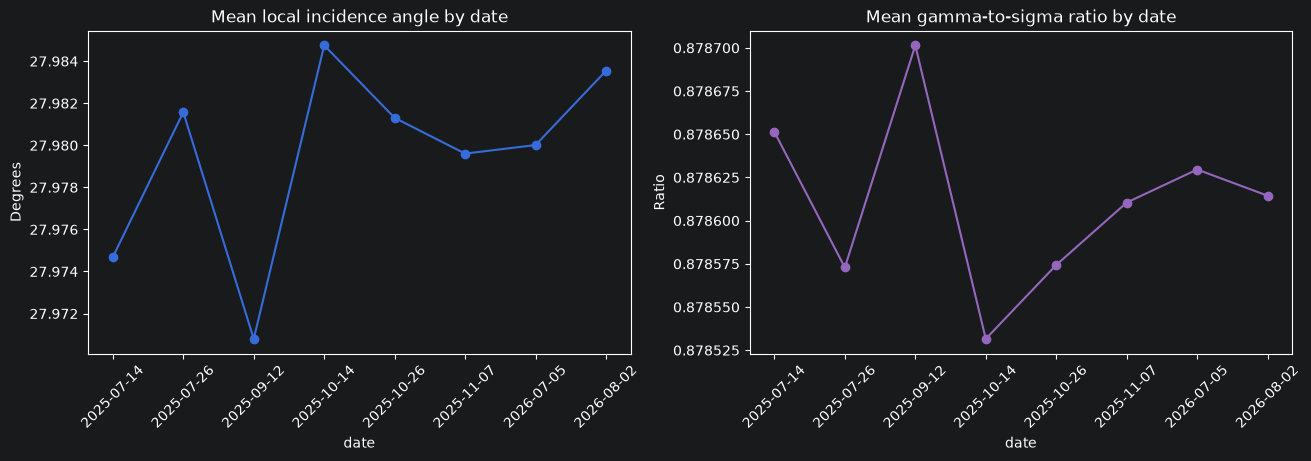

Mean LIA range: 27.97080°–27.98475° (span 0.01396°).
Mean gamma/sigma ratio range: 0.878532–0.878701.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
quality_df.plot(x="date", y="LIA mean °", marker="o", ax=axes[0], legend=False)
axes[0].set_title("Mean local incidence angle by date")
axes[0].set_ylabel("Degrees")
axes[0].tick_params(axis="x", rotation=45)

quality_df.plot(x="date", y="γ/σ mean", marker="o", ax=axes[1], color="tab:purple", legend=False)
axes[1].set_title("Mean gamma-to-sigma ratio by date")
axes[1].set_ylabel("Ratio")
axes[1].tick_params(axis="x", rotation=45)
plt.show()

print(
    f"Mean LIA range: {quality_df['LIA mean °'].min():.5f}°–"
    f"{quality_df['LIA mean °'].max():.5f}° "
    f"(span {quality_df['LIA mean °'].max() - quality_df['LIA mean °'].min():.5f}°)."
)
print(
    f"Mean gamma/sigma ratio range: {quality_df['γ/σ mean'].min():.6f}–"
    f"{quality_df['γ/σ mean'].max():.6f}."
)

## 7. Multi-date radiometric consistency over fixed water and land samples

The fixed Phase 2 samples are reused without retuning. This is a consistency diagnostic, not independent accuracy evidence. For each date the table reports water/land RR medians and standard deviations, their median gap, local-incidence means, and the unchanged Phase 2 lake-mask area.

,date,platform,water n,water median dB,water std dB,land n,land median dB,land std dB,median gap dB,water LIA mean °,land LIA mean °,RR area ha
0,2025-07-14,RCM3,150,-22.511,0.391,192,-11.743,1.071,10.768,27.517,33.385,74.84
1,2025-07-26,RCM3,150,-22.359,0.503,192,-11.290,0.846,11.069,27.514,33.413,70.44
2,2025-09-12,RCM3,150,-22.652,0.679,192,-11.660,0.786,10.992,27.513,33.381,71.08
3,2025-10-14,RCM2,150,-23.806,0.492,192,-10.200,0.919,13.606,27.517,33.417,70.12
4,2025-10-26,RCM2,150,-23.644,0.515,192,-9.696,1.048,13.948,27.514,33.413,70.28
5,2025-11-07,RCM2,150,-22.866,0.946,192,-10.555,1.065,12.312,27.512,33.411,74.80
6,2026-07-05,RCM2,150,-22.421,0.513,192,-11.319,1.172,11.102,27.511,33.308,74.92
7,2026-08-02,RCM3,150,-22.365,0.619,192,-10.813,1.392,11.552,27.514,33.312,70.24


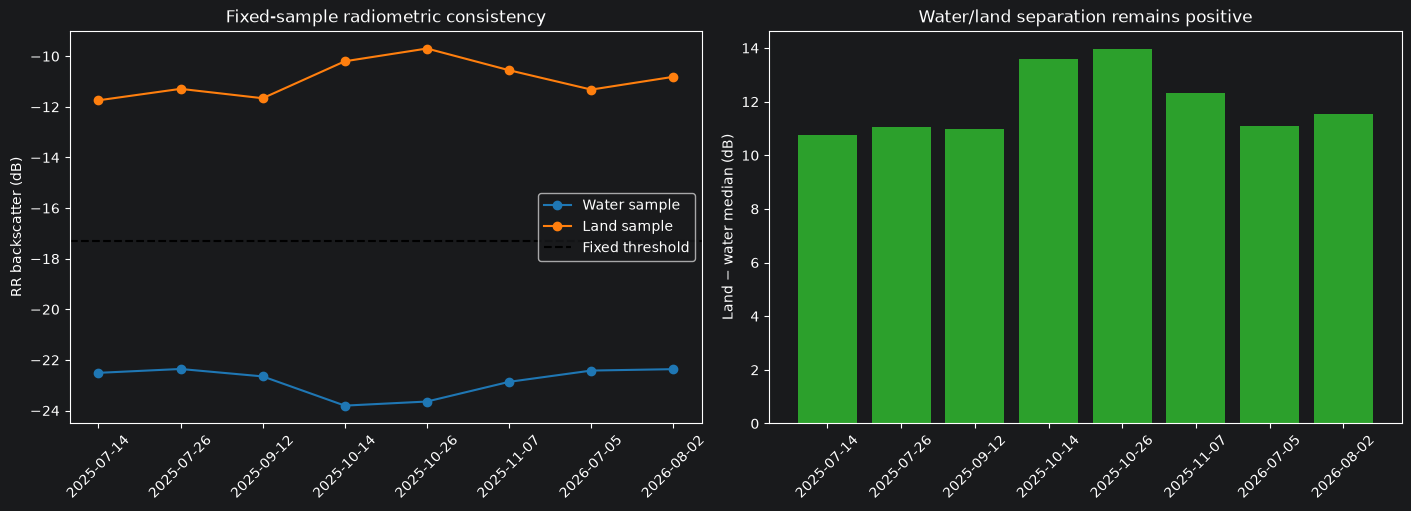

In [7]:
radiometric_rows = []
for date, scene in scenes.items():
    valid = scene["analysis_valid"]
    water = mask_for_geometry(scene, WATER_SAMPLE) & valid
    land = mask_for_geometry(scene, LAND_SAMPLE) & valid
    water_values = scene["rr_db"].data[water]
    land_values = scene["rr_db"].data[land]
    radiometric_rows.append({
        "date": date,
        "platform": platform_from_item(scene["item"]),
        "water n": water_values.size,
        "water median dB": np.median(water_values),
        "water std dB": np.std(water_values, ddof=1),
        "land n": land_values.size,
        "land median dB": np.median(land_values),
        "land std dB": np.std(land_values, ddof=1),
        "median gap dB": np.median(land_values) - np.median(water_values),
        "water LIA mean °": scene["lia"].data[water].mean(),
        "land LIA mean °": scene["lia"].data[land].mean(),
        "RR area ha": scene["water_mask"].sum() * 0.04,
    })

radiometric_df = pd.DataFrame(radiometric_rows)
display(radiometric_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for column, label, color in [
    ("water median dB", "Water sample", "tab:blue"),
    ("land median dB", "Land sample", "tab:orange"),
]:
    axes[0].plot(radiometric_df["date"], radiometric_df[column], marker="o", label=label, color=color)
axes[0].axhline(RR_THRESHOLD_DB, color="black", linestyle="--", label="Fixed threshold")
axes[0].set_ylabel("RR backscatter (dB)")
axes[0].set_title("Fixed-sample radiometric consistency")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

axes[1].bar(radiometric_df["date"], radiometric_df["median gap dB"], color="tab:green")
axes[1].set_ylabel("Land − water median (dB)")
axes[1].set_title("Water/land separation remains positive")
axes[1].tick_params(axis="x", rotation=45)
plt.show()

## 8. RCM-2 versus RCM-3 descriptive comparison

There are only four dates per platform and the platforms are confounded with season/date. The table is descriptive; it cannot establish a platform calibration effect. Comparable area estimates and almost identical local incidence means are reassuring, while the sample backscatter offsets show that the two satellites should still be tracked as a possible nuisance variable.

In [8]:
platform_df = (
    radiometric_df.groupby("platform")[[
        "water median dB", "land median dB", "median gap dB",
        "water LIA mean °", "land LIA mean °", "RR area ha",
    ]]
    .agg(["mean", "std", "min", "max"])
)
display(platform_df.round(3))

platform_means = radiometric_df.groupby("platform").mean(numeric_only=True)
print(
    "Mean RCM2 − RCM3 offsets: "
    f"water {platform_means.loc['RCM2', 'water median dB'] - platform_means.loc['RCM3', 'water median dB']:+.3f} dB, "
    f"land {platform_means.loc['RCM2', 'land median dB'] - platform_means.loc['RCM3', 'land median dB']:+.3f} dB, "
    f"area {platform_means.loc['RCM2', 'RR area ha'] - platform_means.loc['RCM3', 'RR area ha']:+.2f} ha."
)

water median dB                        land median dB                 \
                    mean    std     min     max           mean    std     min   
platform                                                                        
RCM2             -23.184  0.654 -23.806 -22.421        -10.443  0.682 -11.319   
RCM3             -22.472  0.139 -22.652 -22.359        -11.376  0.424 -11.743   

                 median gap dB                        water LIA mean °         \
             max          mean    std     min     max             mean    std   
platform                                                                        
RCM2      -9.696        12.742  1.301  11.102  13.948           27.513  0.003   
RCM3     -10.813        11.095  0.330  10.768  11.552           27.515  0.002   

                         land LIA mean °                        RR area ha  \
             min     max            mean    std     min     max       mean   
platform                                                                     
RCM2      27.511  27.517          33.387  0.053  33.308  33.417      72.53   
RCM3      27.513  27.517          33.373  0.043  33.312  33.413      71.65   

                               
            std    min    max  
platform                       
RCM2      2.692  70.12  74.92  
RCM3      2.157  70.24  74.84

Mean RCM2 − RCM3 offsets: water -0.713 dB, land +0.934 dB, area +0.88 ha.


## 9. Independent authoritative shoreline reference

The [Nova Scotia Hydrographic Network](https://open.canada.ca/data/en/dataset/2ed55c68-b7f8-4db0-15d9-bef40797a4c4) is an official Government of Nova Scotia dataset. Layer 16 (`Wet Features`) is queried through its public ArcGIS REST service, filtering for `Lake Water polygon`; the largest intersecting feature is Folly Lake. Its native geometry is reprojected to EPSG:32620 and retained as vector geometry until rasterization on the RCM grid.

This is an authoritative nominal lake boundary, not a surveyed shoreline for 2025-07-26. Its age, capture method, and generalized shoreline mean that disagreement is not automatically RCM error.

In [9]:
nshn_query = (
    "https://nsgiwa.novascotia.ca/arcgis/rest/services/WTR/"
    "WTR_NSHN_UT83/MapServer/16/query?"
    + urlencode({
        "where": "FEAT_DESC='Lake Water polygon'",
        "geometry": ",".join(map(str, AOI_BBOX)),
        "geometryType": "esriGeometryEnvelope",
        "inSR": "4326",
        "spatialRel": "esriSpatialRelIntersects",
        "outFields": "OBJECTID,HID,FEAT_DESC,SHAPE_Area,SHAPE_Length",
        "returnGeometry": "true",
        "outSR": "4326",
        "f": "geojson",
    })
)
with urlopen(nshn_query, timeout=90) as response:
    nshn_geojson = json.load(response)

folly_feature = max(
    nshn_geojson["features"],
    key=lambda feature: feature["properties"].get("SHAPE_Area") or 0,
)
official_wgs84 = shape(folly_feature["geometry"])
official_gdf = gpd.GeoDataFrame(
    [folly_feature["properties"]], geometry=[official_wgs84], crs="EPSG:4326"
).to_crs(WORKING_CRS)
official_geometry = official_gdf.geometry.iloc[0]

official_record_df = official_gdf.drop(columns="geometry").assign(
    source="Nova Scotia Hydrographic Network — Wet Features",
    full_reprojected_area_ha=official_geometry.area / 10_000,
    crs=WORKING_CRS,
)
display(official_record_df)
print("Official polygon bounds:", tuple(round(value, 2) for value in official_geometry.bounds))

,OBJECTID,HID,FEAT_DESC,SHAPE_Area,SHAPE_Length,source,full_reprojected_area_ha,crs
0,2385,A938C361055748859F18C4E5B3FF36AE,Lake Water polygon,836901.918072,7463.510495,Nova Scotia Hydrographic Network — Wet Features,83.690222,EPSG:32620


Official polygon bounds: (457090.5, 5042142.23, 457854.33, 5044319.16)


## 10. Sentinel-2 source selection and temporal pairing

Sentinel-2 Collection 1 Level-2A is discovered through the public [Element 84 Earth Search STAC API](https://earth-search.aws.element84.com/v1). The candidate with the lowest scene cloud cover in the 2025-07-25 to 2025-07-27 window is selected. The chosen acquisition is on the same UTC date as the RCM validation scene; the exact timestamp difference is calculated below.

Earth Search supplies public Cloud-Optimized GeoTIFFs. Green (`B03`) and NIR (`B08`) are native 10 m surface-reflectance assets; SCL is a native 20 m categorical scene-classification asset.

In [10]:
s2_candidates = list(
    Client.open(S2_STAC).search(
        collections=["sentinel-2-c1-l2a"],
        bbox=AOI_BBOX,
        datetime="2025-07-25T00:00:00Z/2025-07-27T23:59:59Z",
        max_items=None,
    ).items()
)
sentinel_item = min(
    s2_candidates,
    key=lambda item: (item.properties.get("eo:cloud_cover", 100), item.properties["datetime"]),
)
rcm_item = scenes[VALIDATION_DATE]["item"]
rcm_time = pd.to_datetime(rcm_item.properties["datetime"], utc=True)
s2_time = pd.to_datetime(sentinel_item.properties["datetime"], utc=True)
time_offset = abs(s2_time - rcm_time)

sentinel_metadata_df = pd.DataFrame([{
    "item_id": sentinel_item.id,
    "platform": sentinel_item.properties.get("platform"),
    "datetime_utc": sentinel_item.properties["datetime"],
    "paired_RCM_datetime_utc": rcm_item.properties["datetime"],
    "absolute_time_offset_hours": time_offset.total_seconds() / 3600,
    "scene_cloud_cover_%": sentinel_item.properties.get("eo:cloud_cover"),
    "product": "Sentinel-2 Collection 1 Level-2A",
    "green": "B03, 10 m",
    "nir": "B08, 10 m",
    "quality": "SCL, 20 m",
    "crs": sentinel_item.properties.get("proj:code"),
}])
display(sentinel_metadata_df)

,item_id,platform,datetime_utc,paired_RCM_datetime_utc,absolute_time_offset_hours,scene_cloud_cover_%,product,green,nir,quality,crs
0,S2B_T20TMR_20250726T151759_L2A,sentinel-2b,2025-07-26T15:20:18.182000Z,2025-07-26T10:32:24.612236,4.798214,0.005936,Sentinel-2 Collection 1 Level-2A,"B03, 10 m","B08, 10 m","SCL, 20 m",EPSG:32620


## 11. Sentinel-2 reflectance, SCL masking, and NDWI

Earth Search's per-band metadata gives `reflectance = DN × 0.0001 − 0.1`; that scale and offset are applied before the index. NDWI is:

`NDWI = (green − NIR) / (green + NIR)`

Water is provisionally `NDWI > 0`. This conventional, interpretable zero threshold is fixed in advance and is not optimized against RCM. SCL classes 0 (nodata), 1 (saturated/defective), 3 (cloud shadow), 8–10 (cloud/cirrus), and 11 (snow/ice) are invalid. SCL is transferred to the 10 m spectral grid with nearest-neighbour resampling.

,spectral_shape,spectral_resolution_m,SCL_shape,SCL_resolution_m,CRS,scale,offset,SCL counts,invalid/cloud 10 m pixels,valid 10 m pixels,NDWI threshold
0,"(220, 100)",10.0,"(110, 50)",20.0,EPSG:32620,0.0001,-0.1,"2:40, 4:13308, 5:696, 6:6828, 7:1128",0,22000,0.0


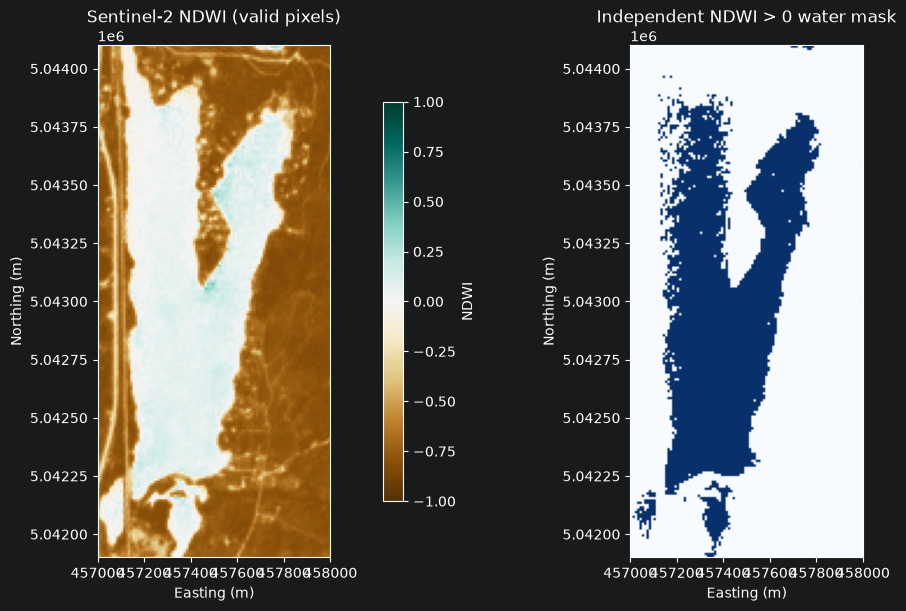

In [11]:
def read_sentinel_window(key, geometry=ANALYSIS_ZONE):
    asset = sentinel_item.assets[key]
    with rasterio.Env(
        GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR",
        CPL_VSIL_CURL_ALLOWED_EXTENSIONS=".tif",
    ):
        with rasterio.open(asset.href) as src:
            source_geometry = transform_geom(WORKING_CRS, src.crs, mapping(geometry))
            window = from_bounds(
                *geometry_bounds(source_geometry), transform=src.transform
            ).round_offsets().round_lengths()
            return (
                src.read(1, window=window, masked=True),
                src.window_transform(window),
                str(src.crs),
                src.nodata,
                tuple(src.res),
            )


green, spectral_transform, spectral_crs, green_nodata, green_res = read_sentinel_window("green")
nir, nir_transform, nir_crs, nir_nodata, nir_res = read_sentinel_window("nir")
scl, scl_transform, scl_crs, scl_nodata, scl_res = read_sentinel_window("scl")
assert green.shape == nir.shape and spectral_transform == nir_transform

raster_band = sentinel_item.assets["green"].extra_fields["raster:bands"][0]
reflectance_scale = float(raster_band["scale"])
reflectance_offset = float(raster_band["offset"])
green_reflectance = green.astype("float64").filled(np.nan) * reflectance_scale + reflectance_offset
nir_reflectance = nir.astype("float64").filled(np.nan) * reflectance_scale + reflectance_offset
ndwi = (green_reflectance - nir_reflectance) / (green_reflectance + nir_reflectance)

scl_10m = np.full(green.shape, 255, dtype=np.uint8)
reproject(
    source=scl.filled(0).astype(np.uint8),
    destination=scl_10m,
    src_transform=scl_transform,
    src_crs=scl_crs,
    dst_transform=spectral_transform,
    dst_crs=spectral_crs,
    src_nodata=0,
    dst_nodata=255,
    resampling=Resampling.nearest,
)

invalid_scl_classes = [0, 1, 3, 8, 9, 10, 11]
ndwi_valid = (
    (~np.ma.getmaskarray(green))
    & (~np.ma.getmaskarray(nir))
    & np.isfinite(ndwi)
    & (green_reflectance >= 0)
    & (nir_reflectance >= 0)
    & (~np.isin(scl_10m, invalid_scl_classes))
    & (scl_10m != 255)
)
optical_10m = np.full(green.shape, 255, dtype=np.uint8)
optical_10m[ndwi_valid] = 0
optical_10m[ndwi_valid & (ndwi > 0.0)] = 1

scl_values, scl_counts = np.unique(scl_10m, return_counts=True)
s2_processing_df = pd.DataFrame([{
    "spectral_shape": str(green.shape),
    "spectral_resolution_m": green_res[0],
    "SCL_shape": str(scl.shape),
    "SCL_resolution_m": scl_res[0],
    "CRS": spectral_crs,
    "scale": reflectance_scale,
    "offset": reflectance_offset,
    "SCL counts": ", ".join(f"{v}:{c}" for v, c in zip(scl_values, scl_counts)),
    "invalid/cloud 10 m pixels": int((~ndwi_valid).sum()),
    "valid 10 m pixels": int(ndwi_valid.sum()),
    "NDWI threshold": 0.0,
}])
display(s2_processing_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
extent_10m = plotting_extent(green, spectral_transform)
ndwi_artist = axes[0].imshow(np.ma.masked_where(~ndwi_valid, ndwi), cmap="BrBG", vmin=-1, vmax=1, extent=extent_10m)
axes[0].set_title("Sentinel-2 NDWI (valid pixels)")
fig.colorbar(ndwi_artist, ax=axes[0], label="NDWI", shrink=0.78)
axes[1].imshow(np.ma.masked_where(optical_10m == 255, optical_10m), cmap="Blues", vmin=0, vmax=1, extent=extent_10m)
axes[1].set_title("Independent NDWI > 0 water mask")
for axis in axes:
    axis.set_xlabel("Easting (m)")
    axis.set_ylabel("Northing (m)")
plt.show()

## 12. Align categorical references to the exact RCM grid

The Sentinel spectral grid and RCM grid already use EPSG:32620 and aligned origins, but their pixels are 10 m and 20 m respectively. The three-state optical class (`water`, `non-water`, `unknown`) is aggregated to 20 m with **mode** resampling. Unknown is retained as nodata. The authoritative polygon is rasterized directly on the RCM grid with center-pixel (`all_touched=False`) semantics. The original source data remain unchanged.

In [12]:
validation_scene = scenes[VALIDATION_DATE]
target_shape = validation_scene["rr_db"].shape
target_transform = validation_scene["transform"]

optical_20m = np.full(target_shape, 255, dtype=np.uint8)
reproject(
    source=optical_10m,
    destination=optical_20m,
    src_transform=spectral_transform,
    src_crs=spectral_crs,
    dst_transform=target_transform,
    dst_crs=validation_scene["crs"],
    src_nodata=255,
    dst_nodata=255,
    resampling=Resampling.mode,
)

official_20m = rasterize(
    [(mapping(official_geometry), 1)],
    out_shape=target_shape,
    transform=target_transform,
    fill=0,
    dtype=np.uint8,
    all_touched=False,
)
rcm_20m = validation_scene["water_mask"].astype(np.uint8)
rcm_valid = validation_scene["analysis_valid"]
optical_valid = optical_20m != 255
common_dynamic_valid = rcm_valid & optical_valid

alignment_df = pd.DataFrame([
    {"layer": "RCM RR class", "source resolution": "20 m", "target": "native RCM", "categorical resampling": "none", "unknown excluded": int((~rcm_valid).sum())},
    {"layer": "Sentinel-2 NDWI class", "source resolution": "10 m", "target": "RCM 20 m", "categorical resampling": "mode", "unknown excluded": int((~optical_valid).sum())},
    {"layer": "NSHN polygon", "source resolution": "vector", "target": "RCM 20 m", "categorical resampling": "center-pixel rasterize", "unknown excluded": 0},
])
display(alignment_df)

,layer,source resolution,target,categorical resampling,unknown excluded
0,RCM RR class,20 m,native RCM,none,9
1,Sentinel-2 NDWI class,10 m,RCM 20 m,mode,0
2,NSHN polygon,vector,RCM 20 m,center-pixel rasterize,0


## 13. Agreement metrics

RCM is treated as the prediction only to make precision/recall directions explicit. For the primary same-day EO comparison, Sentinel-2 NDWI is the reference. All RCM-invalid and optical-invalid/cloud cells are excluded before the confusion matrix is formed.

In [13]:
def agreement_metrics(prediction, reference, valid, label):
    predicted = prediction[valid].astype(bool)
    observed = reference[valid].astype(bool)
    tp = int(np.sum(predicted & observed))
    fp = int(np.sum(predicted & ~observed))
    fn = int(np.sum(~predicted & observed))
    tn = int(np.sum(~predicted & ~observed))
    precision = tp / (tp + fp) if tp + fp else np.nan
    recall = tp / (tp + fn) if tp + fn else np.nan
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else np.nan
    iou = tp / (tp + fp + fn) if tp + fp + fn else np.nan
    predicted_area = predicted.sum() * 0.04
    reference_area = observed.sum() * 0.04
    return {
        "comparison": label,
        "valid pixels": int(valid.sum()),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "precision": precision,
        "recall": recall,
        "F1": f1,
        "IoU": iou,
        "prediction area ha": predicted_area,
        "reference area ha": reference_area,
        "area difference ha": predicted_area - reference_area,
        "area error %": 100.0 * (predicted_area - reference_area) / reference_area,
    }


metrics_df = pd.DataFrame([
    agreement_metrics(rcm_20m, optical_20m, common_dynamic_valid, "RCM RR vs Sentinel-2 NDWI"),
    agreement_metrics(rcm_20m, official_20m, rcm_valid, "RCM RR vs NSHN polygon"),
    agreement_metrics(optical_20m, official_20m, optical_valid, "Sentinel-2 NDWI vs NSHN polygon"),
])
display(metrics_df.round(4))

primary_metrics = metrics_df.iloc[0]
print(
    f"Primary same-day EO validation — precision {primary_metrics['precision']:.3f}, "
    f"recall {primary_metrics['recall']:.3f}, F1 {primary_metrics['F1']:.3f}, "
    f"IoU {primary_metrics['IoU']:.3f}, area error {primary_metrics['area error %']:+.2f}%."
)

,comparison,valid pixels,TP,FP,FN,TN,precision,recall,F1,IoU,prediction area ha,reference area ha,area difference ha,area error %
0,RCM RR vs Sentinel-2 NDWI,5491,1522,239,157,3573,0.8643,0.9065,0.8849,0.7935,70.44,67.16,3.28,4.8839
1,RCM RR vs NSHN polygon,5491,1759,2,301,3429,0.9989,0.8539,0.9207,0.8531,70.44,82.40,-11.96,-14.5146
2,Sentinel-2 NDWI vs NSHN polygon,5500,1607,72,453,3368,0.9571,0.7801,0.8596,0.7538,67.16,82.40,-15.24,-18.4951


Primary same-day EO validation — precision 0.864, recall 0.906, F1 0.885, IoU 0.794, area error +4.88%.


## 14. RCM, independent references, and spatial disagreement

Agreement categories below are RCM-versus-Sentinel: true positive (both water), false positive (RCM only), false negative (Sentinel only), and true negative (both non-water). The NSHN panel provides nominal shoreline context.

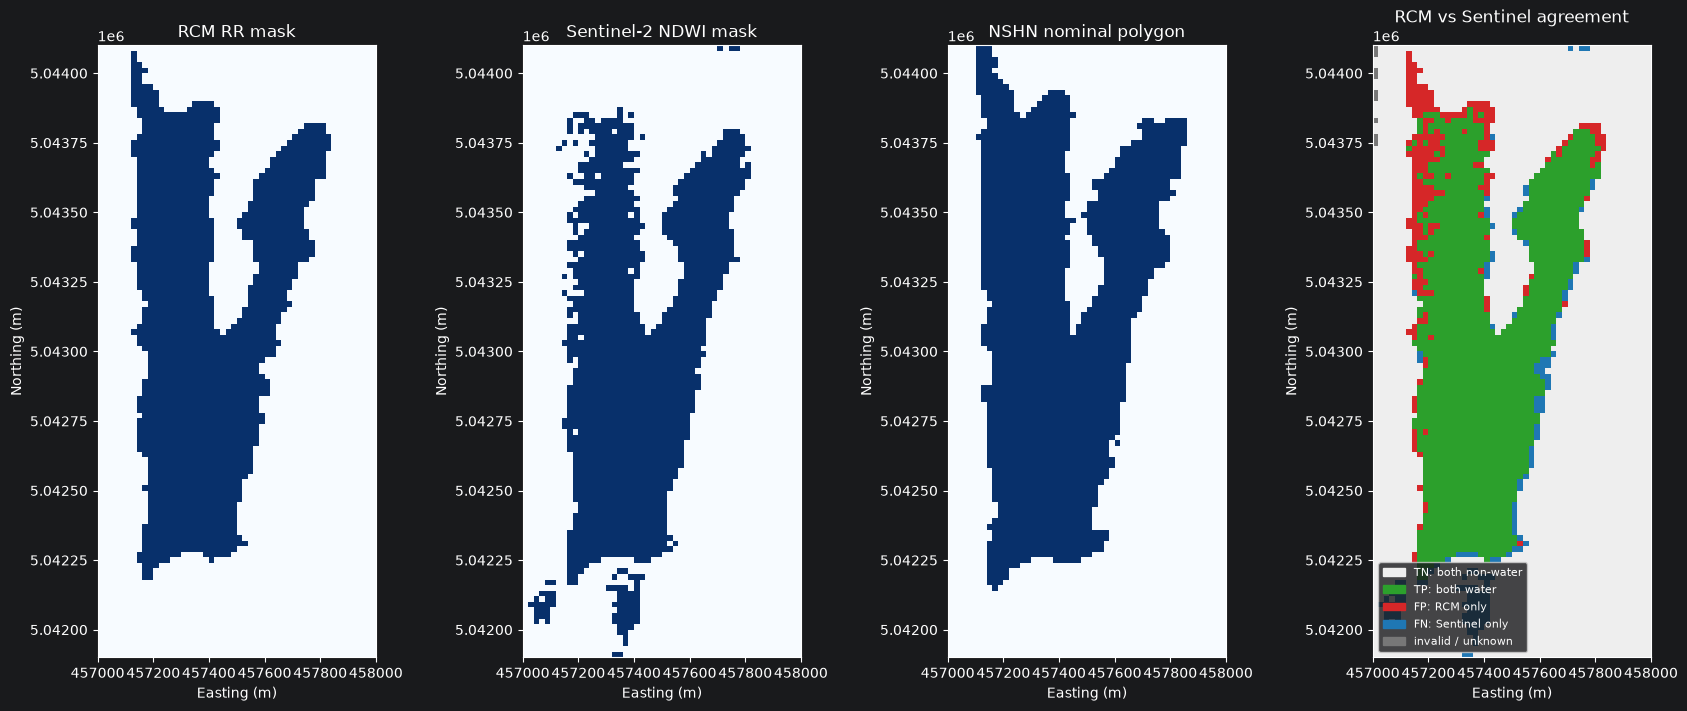

,category,pixels,centroid easting,centroid northing,min easting,max easting,min northing,max northing
0,TP,1522,457408.5,5043041.1,457130.0,457810.0,5042190.0,5043870.0
1,FP,239,457282.4,5043562.6,457130.0,457830.0,5042250.0,5044070.0
2,FN,157,457421.2,5042557.1,457030.0,457790.0,5041910.0,5044090.0
3,TN,3573,457558.2,5042962.0,457010.0,457990.0,5041910.0,5044090.0


In [14]:
agreement = np.full(target_shape, 4, dtype=np.uint8)
agreement[common_dynamic_valid & (rcm_20m == 0) & (optical_20m == 0)] = 0
agreement[common_dynamic_valid & (rcm_20m == 1) & (optical_20m == 1)] = 1
agreement[common_dynamic_valid & (rcm_20m == 1) & (optical_20m == 0)] = 2
agreement[common_dynamic_valid & (rcm_20m == 0) & (optical_20m == 1)] = 3

agreement_colors = ["#eeeeee", "#2ca02c", "#d62728", "#1f77b4", "#777777"]
agreement_labels = ["TN: both non-water", "TP: both water", "FP: RCM only", "FN: Sentinel only", "invalid / unknown"]

fig, axes = plt.subplots(1, 4, figsize=(17, 7), constrained_layout=True)
extent_20m = validation_scene["extent"]
for axis, array, title in zip(
    axes[:3],
    [rcm_20m, np.ma.masked_where(~optical_valid, optical_20m), official_20m],
    ["RCM RR mask", "Sentinel-2 NDWI mask", "NSHN nominal polygon"],
):
    axis.imshow(array, cmap="Blues", vmin=0, vmax=1, extent=extent_20m)
    axis.set_title(title)

axes[3].imshow(agreement, cmap=ListedColormap(agreement_colors), vmin=0, vmax=4, extent=extent_20m)
axes[3].set_title("RCM vs Sentinel agreement")
axes[3].legend(
    handles=[Patch(color=color, label=label) for color, label in zip(agreement_colors, agreement_labels)],
    loc="lower left", fontsize=8,
)
for axis in axes:
    axis.set_xlabel("Easting (m)")
    axis.set_ylabel("Northing (m)")
plt.show()

location_rows = []
for label, category in [("TP", 1), ("FP", 2), ("FN", 3), ("TN", 0)]:
    category_mask = agreement == category
    rows, cols = np.where(category_mask)
    x = target_transform.c + (cols + 0.5) * target_transform.a
    y = target_transform.f + (rows + 0.5) * target_transform.e
    location_rows.append({
        "category": label,
        "pixels": int(category_mask.sum()),
        "centroid easting": x.mean(),
        "centroid northing": y.mean(),
        "min easting": x.min(), "max easting": x.max(),
        "min northing": y.min(), "max northing": y.max(),
    })
location_df = pd.DataFrame(location_rows)
display(location_df.round(1))

## 15. Interpretation of disagreement

The two same-day EO masks agree over most of the lake interior. RCM-only water is concentrated along the western/northwestern lobe and parts of the shoreline; Sentinel-only pixels are fewer and occur mainly around the southern boundary, narrow shore edges, and a few small disconnected patches. Likely contributors include 10-to-20 m aggregation, mixed shoreline pixels, emergent/floating vegetation reducing NDWI, SAR speckle and wind response, and the fixed thresholds. The nominal NSHN polygon is larger than both EO masks within the common AOI, especially around the northern/western mapped boundary.

These patterns are consistent with boundary-method differences. They do not identify which sensor is "correct" at every disputed pixel and do not support a causal environmental claim.

## 16. Source strengths and limitations

| Source | Strengths here | Limitations here |
| --- | --- | --- |
| RCM CEOS-ARD RR | Weather/daylight independent; eight comparable same-orbit dates; strong fixed-sample water/land separation | 20 m mixed pixels; threshold/connectivity dependence; SAR response varies with wind, roughness, vegetation, geometry |
| Sentinel-2 L2A NDWI | Independent optical physics; 10 m spectral data; near-simultaneous and locally cloud-free | NDWI misses vegetated/dark/mixed water; optical classification depends on index threshold and SCL; one validation date only |
| NSHN lake polygon | Official, independent nominal hydrography; stable geometric reference | Not acquisition-date shoreline truth; possible generalization/update lag; northern tip extends beyond the fixed Phase 2 AOI |

The agreement is therefore evidence that the RCM mask captures the lake coherently, not proof of centimetre-accurate shorelines or universal transferability.

## 17. Explicit answers to the Phase 3 validation questions

In [15]:
rcm2 = platform_means.loc["RCM2"]
rcm3 = platform_means.loc["RCM3"]
official_row = metrics_df.loc[metrics_df["comparison"].eq("RCM RR vs NSHN polygon")].iloc[0]

answers = [
    ("1. Are the eight RCM dates pixel-aligned?", "Yes in the tested AOI: same EPSG:32620 CRS, 20 m pixels, 110 × 50 shape, extent, affine origin, and zero measured translation offset."),
    ("2. Was RCM reprojection required?", "No. The native RCM windows already share a common grid, so no continuous backscatter resampling was introduced."),
    ("3. Are nodata/quality flags important?", f"Yes. RR is readable in every AOI cell, but the supplied data mask marks 0–16 layover cells per date; only code 1 is retained."),
    ("4. Is local incidence angle stable?", f"Yes across dates: mean LIA spans only {quality_df['LIA mean °'].min():.5f}° to {quality_df['LIA mean °'].max():.5f}°. Large within-scene ranges still require per-pixel awareness."),
    ("5. Are RCM-2 and RCM-3 identical?", f"Not demonstrated. Their mean areas differ by {rcm2['RR area ha'] - rcm3['RR area ha']:+.2f} ha, but sample medians differ by {rcm2['water median dB'] - rcm3['water median dB']:+.2f} dB (water) and {rcm2['land median dB'] - rcm3['land median dB']:+.2f} dB (land). Date/season confounding and n=4 per platform prevent attribution."),
    ("6. What independent references were used?", "Same-day Sentinel-2 L2A NDWI as a dynamic EO signal, plus the official Nova Scotia Hydrographic Network Folly Lake polygon as nominal hydrography."),
    ("7. Is the Sentinel-2 pairing adequate?", f"Yes for a one-date feasibility check: {sentinel_item.id}, scene cloud {sentinel_item.properties['eo:cloud_cover']:.6f}%, paired {time_offset.total_seconds()/3600:.2f} hours from RCM. The AOI contains no excluded SCL cloud pixels."),
    ("8. How was the optical mask made?", "Scaled L2A B03/B08 reflectance, NDWI > 0, explicit SCL exclusion, then categorical mode aggregation from 10 m to the 20 m RCM grid."),
    ("9. What is same-day precision?", f"{primary_metrics['precision']:.3f}."),
    ("10. What is same-day recall?", f"{primary_metrics['recall']:.3f}."),
    ("11. What are F1 and IoU?", f"F1 = {primary_metrics['F1']:.3f}; IoU = {primary_metrics['IoU']:.3f}."),
    ("12. What is the area error?", f"RCM {primary_metrics['prediction area ha']:.2f} ha versus Sentinel {primary_metrics['reference area ha']:.2f} ha: {primary_metrics['area difference ha']:+.2f} ha ({primary_metrics['area error %']:+.2f}%)."),
    ("13. How does RCM compare with NSHN?", f"F1 = {official_row['F1']:.3f}, IoU = {official_row['IoU']:.3f}; RCM is {official_row['area difference ha']:+.2f} ha ({official_row['area error %']:+.2f}%) relative to the NSHN area inside the fixed AOI."),
    ("14. Where are disagreements?", "Mostly western/northwestern shoreline and lobe for RCM-only water; fewer Sentinel-only pixels along southern/narrow shore edges and small disconnected patches."),
    ("15. Is general agreement useful?", "Yes. The same-day F1/IoU and coherent lake-interior overlap support feasibility, while the boundary disagreements quantify non-negligible absolute-shoreline uncertainty."),
    ("16. Is RCM reliable enough for later relative change detection?", "Conditionally yes for changes clearly larger than the established method noise, with platform/date metadata retained and quality masking enforced. No for small shoreline differences or absolute change claims."),
    ("17. What must Phase 4 preserve?", "Common grid, code-1 data mask, fixed RR rule, platform tracking, uncertainty threshold, and independent validation. Add more cloud-free optical dates before interpreting temporal changes."),
]

for question, answer in answers:
    print(question)
    print("   ", answer)

1. Are the eight RCM dates pixel-aligned?
    Yes in the tested AOI: same EPSG:32620 CRS, 20 m pixels, 110 × 50 shape, extent, affine origin, and zero measured translation offset.
2. Was RCM reprojection required?
    No. The native RCM windows already share a common grid, so no continuous backscatter resampling was introduced.
3. Are nodata/quality flags important?
    Yes. RR is readable in every AOI cell, but the supplied data mask marks 0–16 layover cells per date; only code 1 is retained.
4. Is local incidence angle stable?
    Yes across dates: mean LIA spans only 27.97080° to 27.98475°. Large within-scene ranges still require per-pixel awareness.
5. Are RCM-2 and RCM-3 identical?
    Not demonstrated. Their mean areas differ by +0.88 ha, but sample medians differ by -0.71 dB (water) and +0.93 dB (land). Date/season confounding and n=4 per platform prevent attribution.
6. What independent references were used?
    Same-day Sentinel-2 L2A NDWI as a dynamic EO signal, plus the offi

## 18. Final recommendation for Phase 4

Proceed with RCM RR as the main relative-change signal, but treat the current rule as a **calibrated baseline**, not a final universal detector. The eight RCM scenes require no reprojection in this AOI; enforce the CEOS data mask, preserve the supplied 20 m grid, and retain RCM-2/RCM-3 as a diagnostic grouping. Same-day optical validation is encouraging (high precision/recall and coherent interior overlap), while shoreline disagreement and the NSHN area difference show that absolute area remains method-sensitive.

Phase 4 should flag changes only when they exceed the Phase 2 stability/sensitivity envelope and should add multiple independent optical dates if available. Folly Lake should continue to be described as a stable control/calibration site; no result here is evidence of climate-driven or environmental change.

## 19. Reproducibility and data-handling notes

- Run with the registered kernel **Python 3.12 (Space Hackathon 2026)**.
- Internet access is required for STAC metadata, remote COG byte-range reads, product XML, and the public NSHN query.
- No secrets or credentials are required.
- No raw scene, processed raster, or derived array is written to the repository.
- Authoritative/reference URLs:
  - [EODMS STAC](https://www.eodms-sgdot.nrcan-rncan.gc.ca/search)
  - [NRCan RCM example notebooks](https://github.com/eodms-sgdot/radarsat-notebooks)
  - [Nova Scotia Hydrographic Network](https://open.canada.ca/data/en/dataset/2ed55c68-b7f8-4db0-15d9-bef40797a4c4)
  - [Earth Search Sentinel-2 L2A collection](https://earth-search.aws.element84.com/v1/collections/sentinel-2-c1-l2a)
  - [Sentinel-2 Level-2A algorithm basis](https://sentinels.copernicus.eu/documents/247904/446933/Sentinel-2-Level-2A-Algorithm-Theoretical-Basis-Document-ATBD.pdf)